# Import Library

In [9]:
import cv2
import time
import numpy as np
import matplotlib.pyplot as plt

# Definisi Keypoints dan Skeleton

In [10]:
n_points = 25

body_parts = {
    "Nose": 0, "Neck": 1,
    "RShoulder": 2, "RElbow": 3, "RWrist": 4,
    "LShoulder": 5, "LElbow": 6, "LWrist": 7,
    "MidHip": 8,
    "RHip": 9, "RKnee": 10, "RAnkle": 11,
    "LHip": 12, "LKnee": 13, "LAnkle": 14,
    "REye": 15, "LEye": 16,
    "REar": 17, "LEar": 18,
    "LBigToe": 19, "LSmallToe": 20, "LHeel": 21,
    "RBigToe": 22, "RSmallToe": 23, "RHeel": 24,
    "Background": 25
}

pose_pairs = [
    ["Neck", "MidHip"],
    ["Neck", "RShoulder"], ["RShoulder", "RElbow"], ["RElbow", "RWrist"],
    ["Neck", "LShoulder"], ["LShoulder", "LElbow"], ["LElbow", "LWrist"],
    ["MidHip", "RHip"], ["RHip", "RKnee"], ["RKnee", "RAnkle"],
    ["MidHip", "LHip"], ["LHip", "LKnee"], ["LKnee", "LAnkle"],
    ["Neck", "Nose"], ["Nose", "REye"], ["REye", "REar"],
    ["Nose", "LEye"], ["LEye", "LEar"],
    ["LAnkle", "LBigToe"], ["LBigToe", "LSmallToe"], ["LAnkle", "LHeel"],
    ["RAnkle", "RBigToe"], ["RBigToe", "RSmallToe"], ["RAnkle", "RHeel"]
]

# Load Model Caffe

In [11]:
proto_file = "models/pose_deploy.prototxt"
weights_file = "models/pose_iter_584000.caffemodel"
net = cv2.dnn.readNetFromCaffe(proto_file, weights_file)

# Load Gambar dan Preprocessing

In [12]:
image = cv2.imread("images/tennis_guy.jpg")
height, width = image.shape[:2]
blob = cv2.dnn.blobFromImage(image, 1.0 / 255, (368,368), (0, 0, 0), swapRB=False, crop=False)
net.setInput(blob)

# Prediksi Pose dengan Model

In [13]:
output = net.forward()

# Visualisasi Heatmap

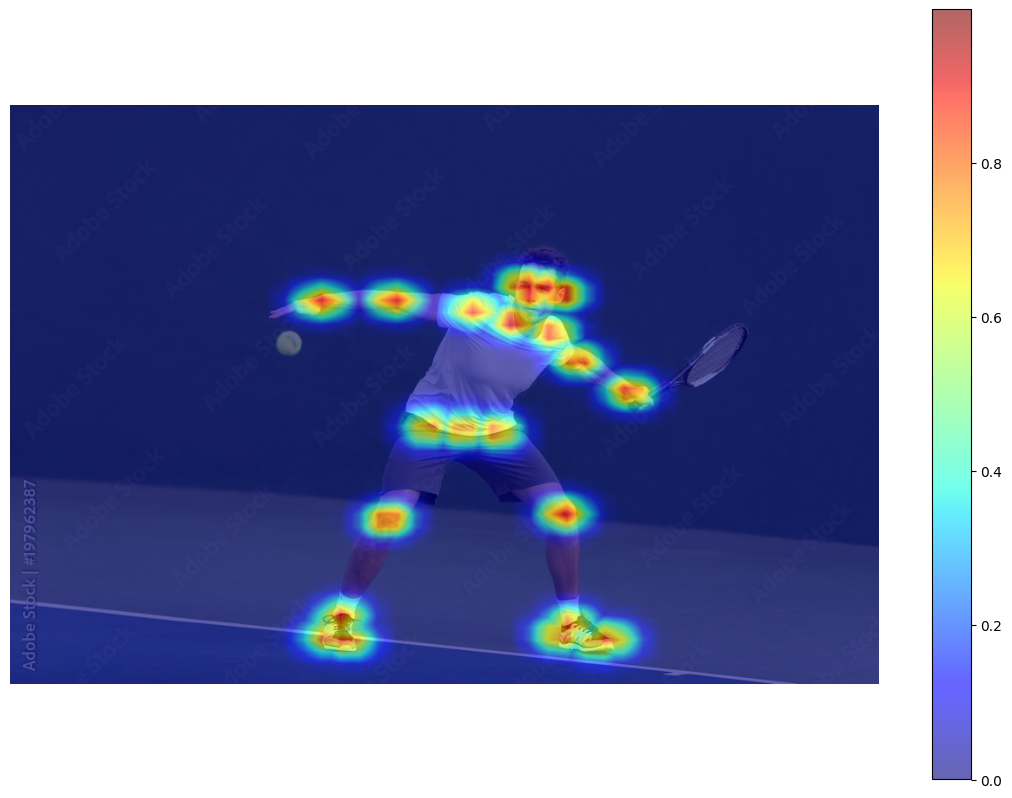

In [14]:
h, w = output.shape[2:4]

prob_map = np.zeros((height, width), dtype=np.float32)

for i in range(n_points):
    pmap = output[0, i, :, :]
    pmap = cv2.resize(pmap, (width, height))
    prob_map = np.maximum(prob_map, pmap)

prob_map = cv2.normalize(prob_map, None, 0, 1, cv2.NORM_MINMAX)

plt.figure(figsize=[14, 10])
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.imshow(prob_map, alpha=0.6, cmap="jet")
plt.colorbar()
plt.axis("off")
plt.show()

# Deteksi dan Plot Keypoints

In [15]:
threshold = 0.1
image1 = image.copy()
points = []

for i in range(n_points):
    prob_map = output[0, i, :, :] # confidence map of corresponding body's part.
    min_val, prob, min_loc, point = cv2.minMaxLoc(prob_map)
    # scale the point to fit on the original image
    x = (width * point[0]) / w
    y = (height * point[1]) / h

    if prob > threshold :
        cv2.circle(image1, (int(x), int(y)), 8, (255, 0, 255), thickness=-1, lineType=cv2.FILLED)
        cv2.putText(image1, "{}".format(i), (int(x), int(y)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2, lineType=cv2.LINE_AA)
        cv2.circle(image, (int(x), int(y)), 8, (255, 0, 255), thickness=-1, lineType=cv2.FILLED)
        points.append((int(x), int(y)))
        
    else :
        points.append(None)

# Keypoints dan Pose

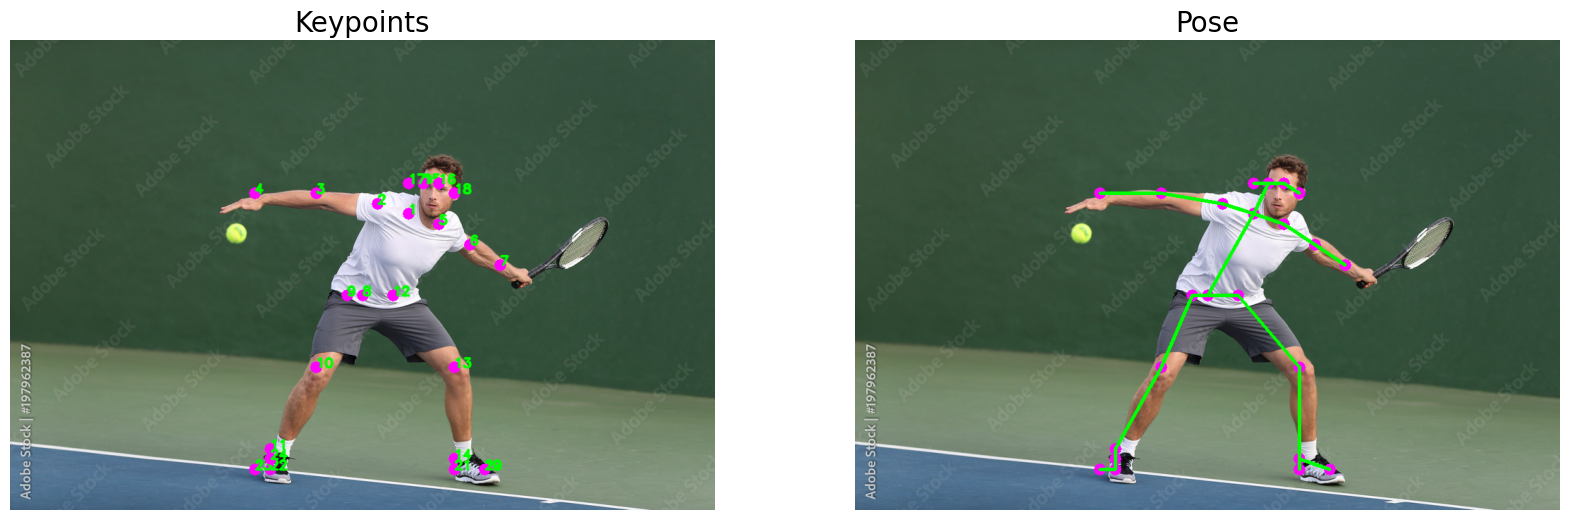

In [16]:
for pair in pose_pairs:
    part_from = body_parts[pair[0]]
    part_to = body_parts[pair[1]]
    if points[part_from] and points[part_to]:
        cv2.line(image, points[part_from], points[part_to], (0, 255, 0), 3)

plt.figure(figsize=[20,12])
plt.subplot(121), plt.imshow(cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)), plt.axis('off'), plt.title('Keypoints', size=20)
plt.subplot(122), plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)), plt.axis('off'), plt.title('Pose', size=20)
plt.show()